In [2]:
%matplotlib notebook
import matplotlib.pyplot as plt
import numpy as np

plt.subplot?

<IPython.core.display.Javascript object>


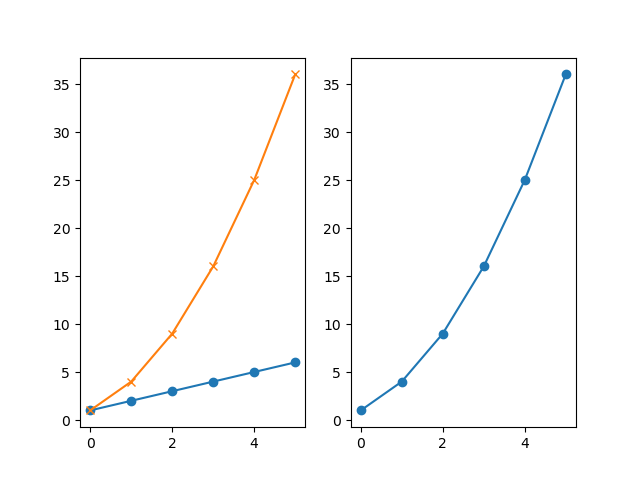

In [3]:
plt.figure()
plt.subplot(1, 2, 1)

linear_data = np.array([1, 2, 3, 4, 5, 6])
plt.plot(linear_data, '-o')

In [4]:
exponential_data = linear_data ** 2
plt.subplot(1, 2, 2)
plt.plot(exponential_data, '-o')

In [5]:
plt.subplot(1, 2, 1)
plt.plot(exponential_data, '-x')

C:\Users\Poornartha Sawant\anaconda3\lib\site-packages\ipykernel_launcher.py:1: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  """Entry point for launching an IPython kernel.


<IPython.core.display.Javascript object>


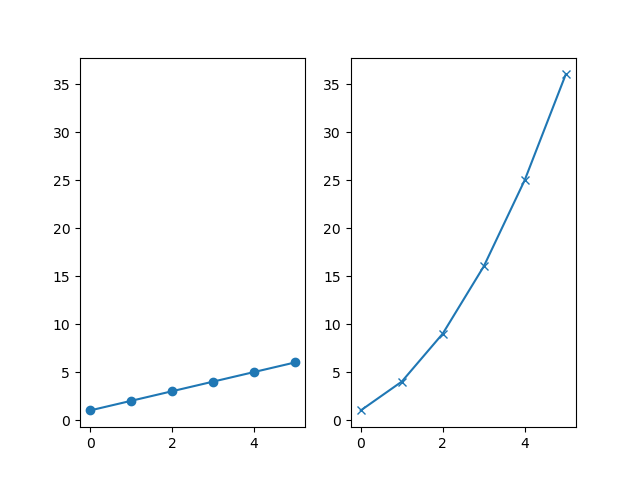

In [6]:
plt.figure()
ax1 = plt.subplot(1, 2, 1)
plt.plot(linear_data, '-o')
ax2 = plt.subplot(1, 2, 2, sharey=ax1)
plt.plot(exponential_data, '-x')

<IPython.core.display.Javascript object>


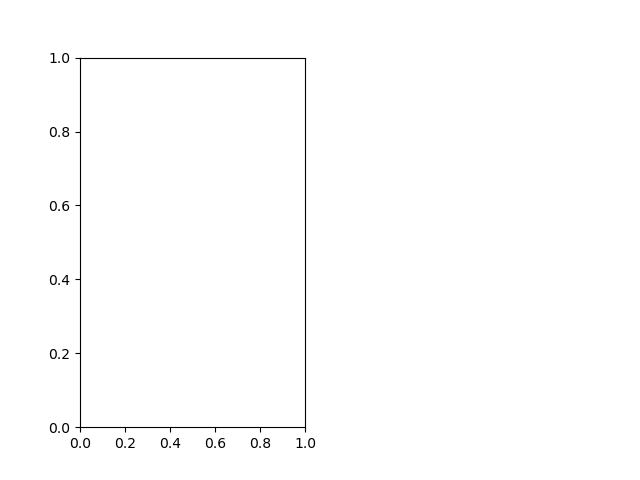

C:\Users\Poornartha Sawant\anaconda3\lib\site-packages\ipykernel_launcher.py:2: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  


True

In [7]:
plt.figure()
plt.subplot(1,2,1) == plt.subplot(121)

<IPython.core.display.Javascript object>


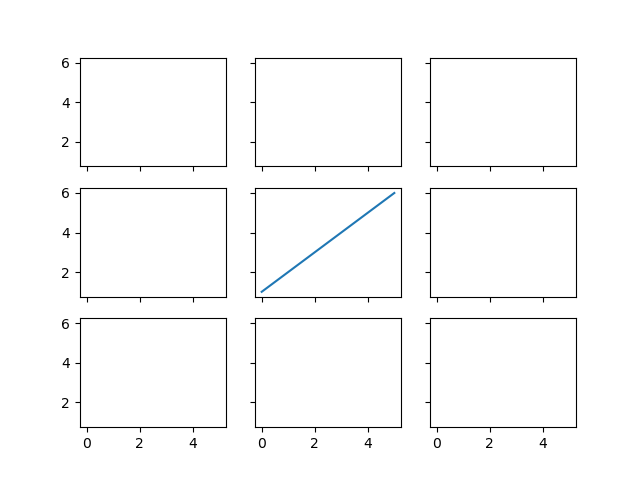

In [19]:
# To make a 3x3 subplot:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3, 3,
                                                                       sharex = True,
                                                                       sharey = True )
ax5.plot(linear_data, '-')

In [21]:
for ax in plt.gcf().get_axes():
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_visible(True)
plt.gcf().canvas.draw()

 ### Histograms

<IPython.core.display.Javascript object>


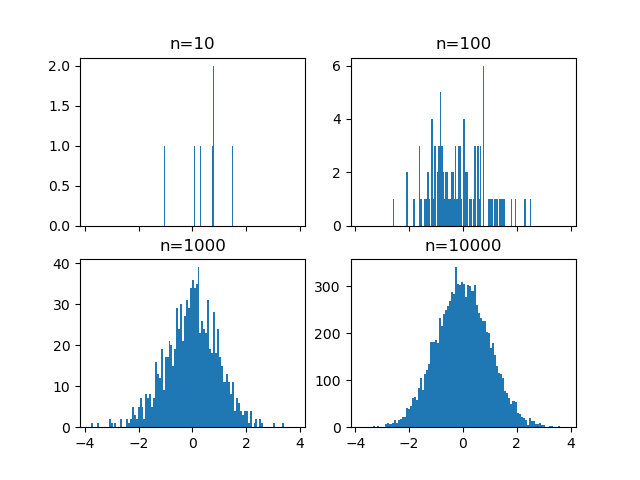

In [25]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, sharex=True)
axs = [ax1, ax2, ax3, ax4]

for n in range(0, len(axs)):
    sample_size = 10 ** (n+1)
    sample = np.random.normal(loc=0.0, scale=1.0, size=sample_size)
    axs[n].hist(sample, bins=100)
    axs[n].set_title('n={}'.format(sample_size))

<IPython.core.display.Javascript object>


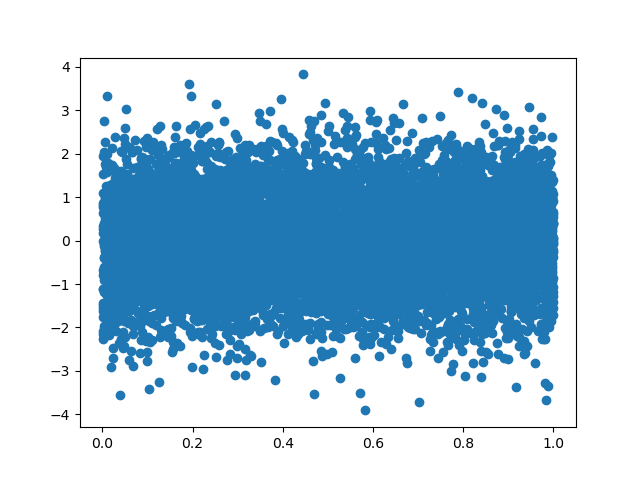

In [26]:
plt.figure()
Y = np.random.normal(loc=0.0, scale=1.0, size=10000)
X = np.random.random(size=10000)
plt.scatter(X, Y)

<IPython.core.display.Javascript object>


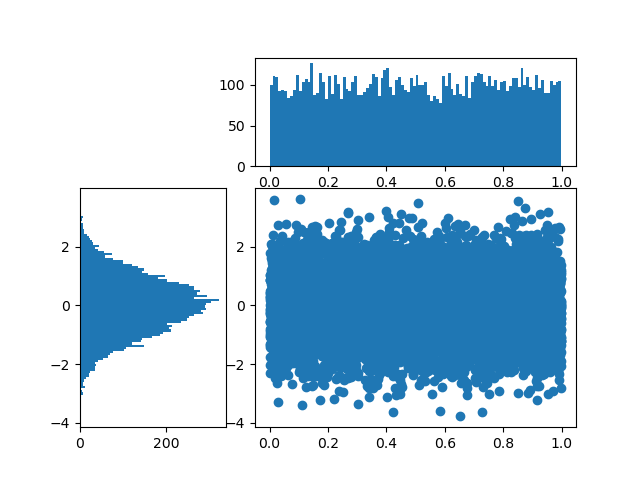

In [40]:
import matplotlib.gridspec as gridspec

plt.figure()
gspec = gridspec.GridSpec(3, 3)

top_histogram = plt.subplot(gspec[0, 1:])
side_histogram = plt.subplot(gspec[1:, 0])
lower_right = plt.subplot(gspec[1:, 1:])

In [41]:
Y = np.random.normal(loc=0.0, scale=1.0, size=10000)
X = np.random.random(size=10000)
lower_right.scatter(X, Y)
top_histogram.hist(X, bins=100)
s = side_histogram.hist(Y, bins=100, orientation='horizontal')

In [43]:
top_histogram.clear()
top_histogram.hist(X, bins=100, normed=True)
side_histogram.clear()
side_histogram.hist(Y, bins=100, orientation='horizontal', normed=True)
# flip the side histogram's x axis
side_histogram.invert_xaxis()
for ax in [top_histogram, lower_right]:
    ax.set_xlim(0, 1)
for ax in [side_histogram, lower_right]:
    ax.set_ylim(-5, 5)

AttributeError: 'Rectangle' object has no property 'normed'

### Box Plots and Whiskers Plot:

In [47]:
import pandas as pd
normal_sample = np.random.normal(loc=0.0, scale=1.0, size=10000)
random_sample = np.random.random(size=10000)
gamma_sample = np.random.gamma(2, size=10000)

df = pd.DataFrame({
    'normal': normal_sample,
    'random': random_sample,
    'gamma': gamma_sample
})
df.describe()

,normal,random,gamma
count,10000.000000,10000.000000,10000.000000
mean,-0.013520,0.499104,1.995270
std,1.001883,0.289880,1.398371
min,-3.476455,0.000029,0.013817
25%,-0.687744,0.249328,0.964738
50%,-0.015274,0.498072,1.665936
75%,0.661635,0.755157,2.677861
max,3.870559,0.999876,11.164580


<IPython.core.display.Javascript object>


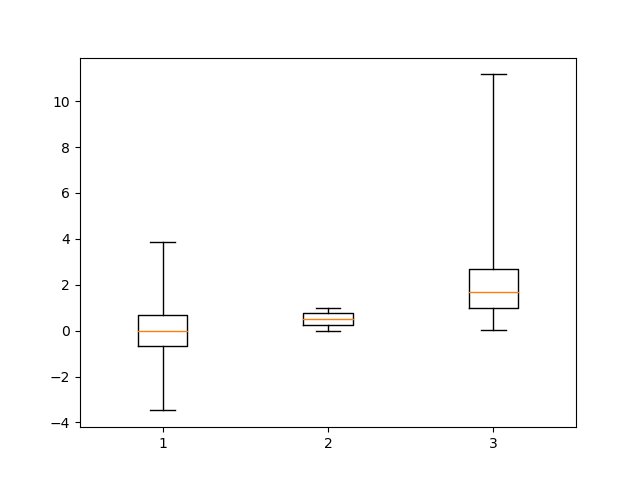

C:\Users\Poornartha Sawant\anaconda3\lib\site-packages\ipykernel_launcher.py:2: MatplotlibDeprecationWarning: Setting whis to 'range' is deprecated since 3.2 and support for it will be removed two minor releases later; set it to [0, 100] to achieve the same effect.
  


In [48]:
plt.figure()
_ = plt.boxplot(df['normal'], whis='range')

In [50]:
plt.clf()
_ = plt.boxplot([df['normal'], df['random'], df['gamma']], whis='range')

C:\Users\Poornartha Sawant\anaconda3\lib\site-packages\ipykernel_launcher.py:2: MatplotlibDeprecationWarning: Setting whis to 'range' is deprecated since 3.2 and support for it will be removed two minor releases later; set it to [0, 100] to achieve the same effect.
  


<IPython.core.display.Javascript object>


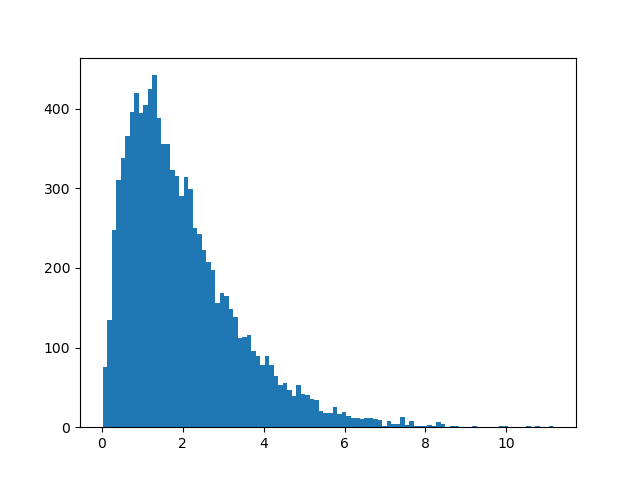

In [51]:
plt.figure()
_ = plt.hist(df['gamma'], bins=100)

#### Using MPL Toolkit 

<IPython.core.display.Javascript object>


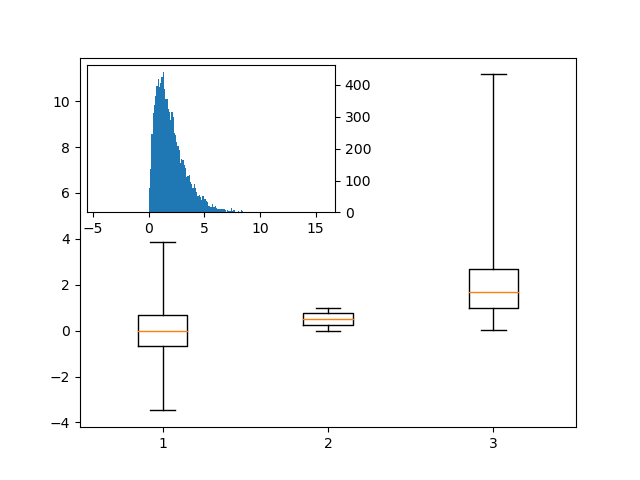

C:\Users\Poornartha Sawant\anaconda3\lib\site-packages\ipykernel_launcher.py:4: MatplotlibDeprecationWarning: Setting whis to 'range' is deprecated since 3.2 and support for it will be removed two minor releases later; set it to [0, 100] to achieve the same effect.
  after removing the cwd from sys.path.


In [62]:
import mpl_toolkits.axes_grid1.inset_locator as mpl_il

plt.figure()
plt.boxplot([ df['normal'], df['random'], df['gamma'] ], whis='range')
# overlay axis on top of another 
ax2 = mpl_il.inset_axes(plt.gca(), width='50%', height='40%', loc=2)
ax2.hist(df['gamma'], bins=100)
ax2.margins(x=0.5)
ax2.yaxis.tick_right()

<IPython.core.display.Javascript object>


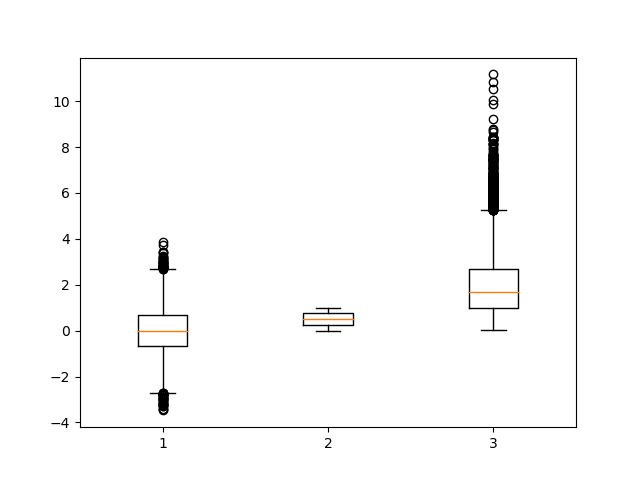

In [63]:
plt.figure()
_ = plt.boxplot([ df['normal'], df['random'], df['gamma'] ] )

# HeatMaps

<IPython.core.display.Javascript object>


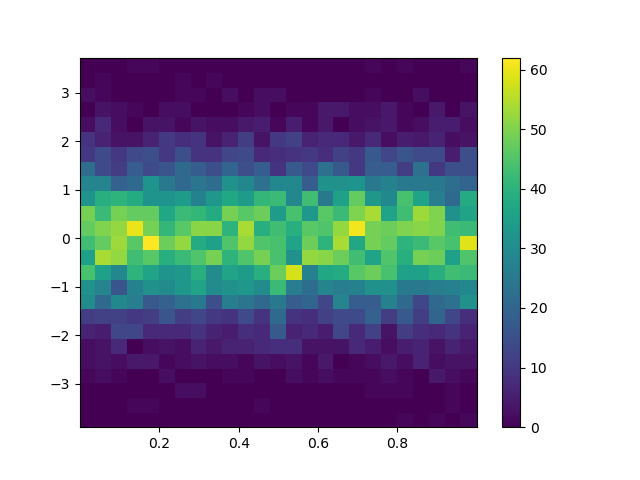

<IPython.core.display.Javascript object>


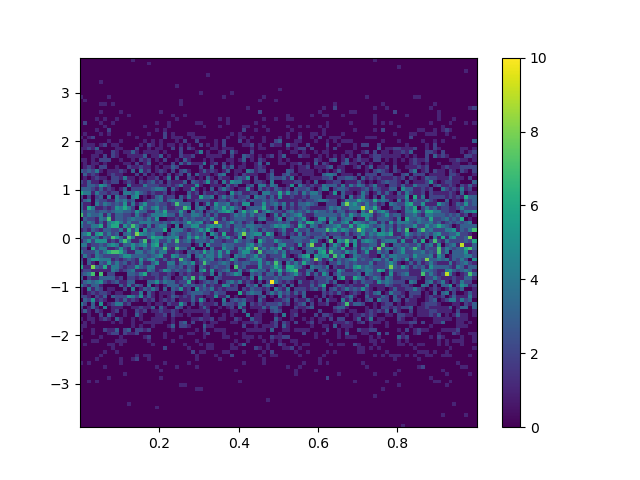

In [65]:
plt.figure()

Y = np.random.normal(loc=0.0, scale=1.0, size=10000)
X = np.random.random(size=10000)
_ = plt.hist2d(X, Y, bins=25) 
plt.colorbar()
plt.figure()
_ = plt.hist2d(X, Y, bins=100)
plt.colorbar()

# Animations:

<IPython.core.display.Javascript object>


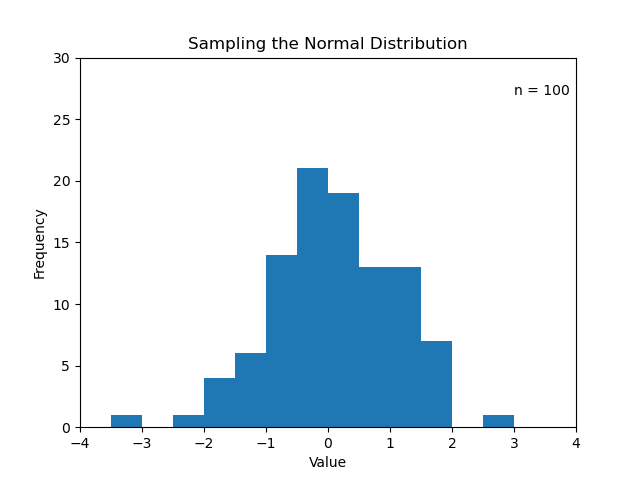

In [82]:
import matplotlib.animation as animation

n = 100
x = np.random.randn(n)

# create the function that will do the plotting, where curr is the current frame
def update(curr):
    # check if animation is at the last frame, and if so, stop the animation a
    if curr == n: 
        a.event_source.stop()
    plt.cla()
    bins = np.arange(-4, 4, 0.5)
    plt.hist(x[:curr], bins=bins)
    plt.axis([-4,4,0,30])
    plt.gca().set_title('Sampling the Normal Distribution')
    plt.gca().set_ylabel('Frequency')
    plt.gca().set_xlabel('Value')
    plt.annotate('n = {}'.format(curr), [3,27])

fig = plt.figure()
a = animation.FuncAnimation(fig, update, interval=100)

<IPython.core.display.Javascript object>


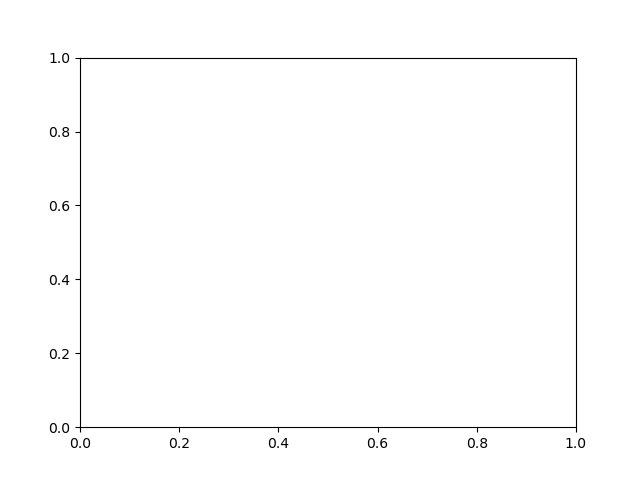